In [188]:

import torch
import pyro
import pyro.distributions as dist
from pyro.infer import MCMC, NUTS, HMC
from IPython.core.pylabtools import figsize
import numpy as np
import pandas as pd

from pathlib import Path
import glob
from matplotlib import pyplot as plt
from scipy.stats.mstats import mquantiles
from sklearn.preprocessing import MinMaxScaler

from pyro.infer.autoguide import init_to_value


# Parameter determination for function
Goal here is to extract peak centers using the Pyro Bi-Lorentzian model and then build a simple regression model using those values. The peak centers come with uncertainties, to first order approx, we assume these uncertainties are the largest driver of predicted temperatrure uncertainties

## Set up function
Here we import the data, define a bi-gaussian function and demonstrate the impact of different values of center 1 and center 2 (A and B, respectively) on the simulated spectra.  We drop the last point the first and last obs. the first obs was made with lower laser power (and as such can introduce uncertainty) and the last observation appears to be an outlier. Records indicate the set temp was 0.0 C but the spectra is near match to -20.0 C. It is either a recording error or an operator error i.e. I forgot to hit enter on the drywell after keying in the new temp value (0 C)

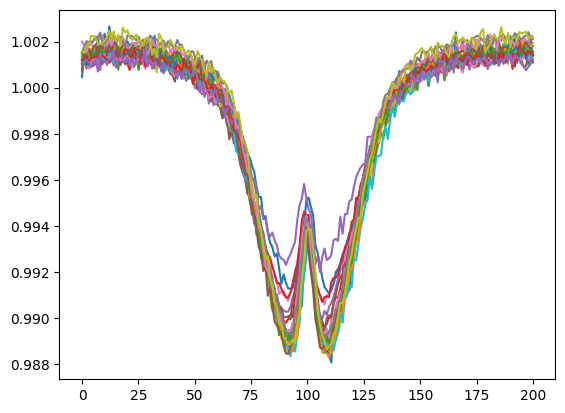

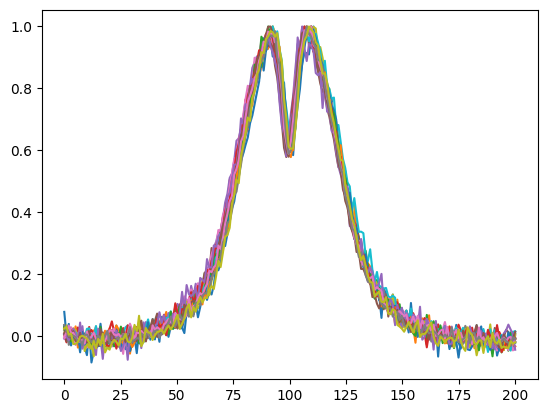

In [189]:
fpath_pcb = '../saved_data/pcb_microdiamond_cycles_1_and_2'

df_pcb = pd.read_csv(fpath_pcb, header = 0)


x_esr_ = df_pcb.iloc[:, 1]
y_esr_new = df_pcb.iloc[:, 2:]

sc = MinMaxScaler(feature_range=(0, 200))
x_esr_new = sc.fit_transform(x_esr_.values.reshape(-1, 1)).flatten()

plt.plot(x_esr_new, y_esr_new);plt.show()

# define and scale the frequency axis 
y_esr_new = y_esr_new.apply(lambda x: x - x[:10].mean())#+0.01
y_esr_new = -1*y_esr_new
y_esr_new = y_esr_new.apply(lambda x: x/x.max())
plt.plot(x_esr_new, y_esr_new);


In [190]:
# temps_ = df_pcb.columns
measured_temp = np.array([25, 30, 35, 40, 45, 45.1, 40.1,
       35.1, 30.1, 25.1, 25.2, 30.2, 35.2, 40.2, 45.2,
       40.1, 35.1, 30.1, 25.1])

In [191]:
y_esr_new.shape

(200, 19)

In [192]:
from scipy.signal import find_peaks

peak_A, peak_B = [], []

for j in range(y_esr_new.shape[1]):
    y_ = y_esr_new.iloc[:, j].values
    peaks, properties = find_peaks(
        y_,
        height=0.75,      # minimum peak height
        distance=5,      # minimum spacing (points)
        prominence=0.02   # suppress noise
    )
    peak_A.append(peaks[0])    
    peak_B.append(peaks[1])
    


Text(0, 0.5, 'peak A position')

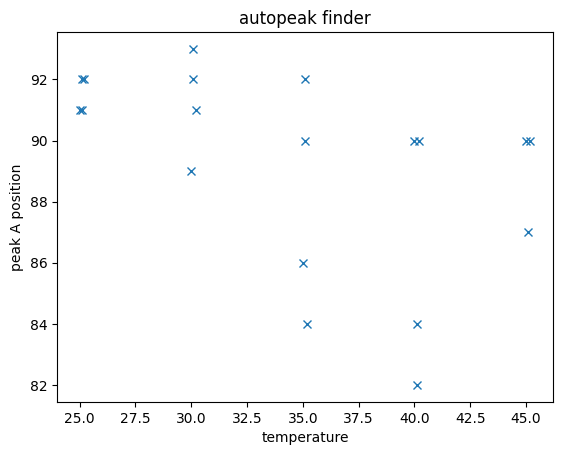

In [193]:
plt.plot(measured_temp, peak_A, 'x')
plt.title('autopeak finder')
plt.xlabel('temperature')
plt.ylabel('peak A position')

In [194]:
#numpy version of function
def F_np(x_in,  a1, b1, c1, X1,   A, X, Amp, G1):
    # Reshape A, B, Amp, G1, G2 for broadcasting with x_in
    X1_reshaped = X1[None, :]  # Shape (1, num_samples)
    a1_reshaped = a1[None, :] # Shape (1, num_samples)
    b1_reshaped = b1[None, :]   # Shape (1, num_samples)
    b2_reshaped = b1_reshaped + X1_reshaped  # Shape (1, num_samples)
    c1_reshaped = c1[None, :] # Shape (1, num_samples)
    x_in_reshaped = x_in[:, None] # Shape (num_x_points, 1)
    A_reshaped = A[None, :]  # Shape (1, num_samples)
    X_reshaped = X[None, :]  # Shape (1, num_samples)
    B_reshaped = A_reshaped + X_reshaped  # Shape (1, num_samples)
    Amp_reshaped = Amp[None, :] # Shape (1, num_samples)
    G1_reshaped = G1[None, :] # New: Reshape gamma1
    
    F1 =  ( (a1_reshaped  * np.exp(-1 * (x_in_reshaped - b1_reshaped)**2 / (2 * c1_reshaped)**2) ) \
        +  ( a1_reshaped   * np.exp(-1 * (x_in_reshaped - b2_reshaped)**2 / (2 * c1_reshaped)**2  )) )
    
    F2 = (Amp_reshaped) * (0.5 * G1_reshaped) / ((x_in_reshaped - A_reshaped)**2 + (0.5 * G1_reshaped)**2) \
        + (Amp_reshaped) * (0.5 * G1_reshaped) / ((x_in_reshaped - B_reshaped)**2 + (0.5 * G1_reshaped)**2)
    
    F = F1 + F2

    return F, F1, F2


## Define data we will start with and plot.

In [195]:

# this will be the data we'll start with, shown as red circles
def dataslicer(x, y, col1 =1 ,col2=2):
    x_scale_tensor = torch.tensor(x).double()
    # squeeze the selected column to produce a 1-D tensor (N,) instead of (N,1)
    y_vals = y.iloc[:, col1:col2].values.squeeze()
    y_scale_tensor = torch.tensor(y_vals).double()
    return x_scale_tensor, y_scale_tensor



## Set up and run Bayesian inference

In [196]:
# define the model
# Here we assume that we know the noise variance in the data = 0.1,
# though this can be set to another parameter to learn.

x_obs, y_obs = dataslicer(x_esr_new, y_esr_new, col1=0, col2=1)
data = (x_obs.clone().detach().double(), y_obs.clone().detach().double())


def model(data):
    b1 = pyro.sample("b1", dist.Normal(86., 3.0)) # sample a value for A uniformly between 0 and 10
    X1 =  pyro.sample("X1", dist.Normal(32.5, 1.0))
    b2 = b1 - X1 # sample a value for B uniformly between 0 and 10
    c1 = pyro.sample("c1", dist.Normal(8., 0.5)) #+ 0.55
    var = pyro.sample("var", dist.HalfNormal(scale=0.1))
    a1 = pyro.sample("a1", dist.Normal(0.55, 0.1)) 
    A = pyro.sample("A", dist.Normal(92., 1.0)).double() # sample a value for A uniformly between 0 and 10
    X =  pyro.sample("X", dist.Normal(16.5, 0.5)).double()
    B = A + X # sample a value for B uniformly between 0 and 10
    gamma1 = pyro.sample("gamma1", dist.Normal(9.0, 1.5)).double()
    amp = pyro.sample("amp", dist.LogNormal(3.0, 0.25)).double()

    F1 =    ( (a1  * torch.exp(-1 * (data[0] - b1)**2 / (2 * c1)**2) )\
        +    (a1  * torch.exp(-1 * (data[0] - b2)**2 / (2 * c1)**2) ) )
    
    F2 =   (amp) * (0.5 * gamma1) / ((data[0] - A)**2 + (0.5 * gamma1)**2) \
        + (amp) * (0.5 * gamma1) / ((data[0] - B)**2 + (0.5 * gamma1)**2)
    F = F1 + F2
    # ensure F is a 1-D mean vector matching y_obs
    F = F.squeeze()

    #with pyro.plate("data", data[0].size(0)):
    # pyro.sample("obs", dist.MultivariateNormal(F, var * torch.eye(data[1].shape[0])), obs=data[1])
    with pyro.plate("data", data[0].size(0)):
        pyro.sample("obs", dist.Normal(F, torch.sqrt(var)), obs=data[1])


In [204]:
init_vals = {

    "a1" : torch.tensor( 0.55),
    "c1" : torch.tensor( 8.0),
    "b1" : torch.tensor( 86.0),
    "A" : torch.tensor( 92.0),
    "X1" : torch.tensor( 32.5),
    "X" : torch.tensor( 16.5),
    "var" : torch.tensor( 0.0015), 
    "gamma1" : torch.tensor(9.0),
    "amp" : torch.tensor(2.20)
}



In [205]:
# solve for the posterior using MCMC
kernel = NUTS(model, jit_compile=True, init_strategy=init_to_value(values=init_vals), ignore_jit_warnings=True, max_tree_depth=3) # 
posterior = MCMC(kernel, num_samples=500, warmup_steps=500, num_chains=1)
posterior.run((data))

Sample: 100%|██████████| 1000/1000 [00:26, 38.08it/s, step size=4.23e-01, acc. prob=0.895]


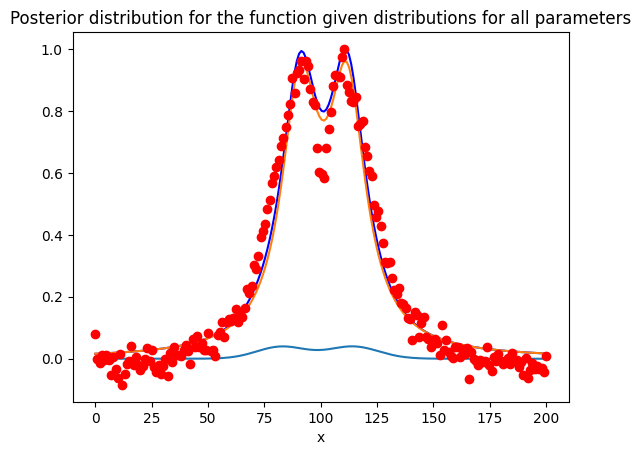

In [206]:
# get the MCMC samples for center A and center B, variance (var), amplitude (amp), and linewidth (gamma1) and plot histogram for each. 
# note gamma1 is used for both peaks in this model.


hmc_samples = {k: v.detach().cpu().numpy() for k, v in posterior.get_samples().items()}

a1 = hmc_samples['a1'] 
c1 = hmc_samples['c1'] 
b1 = hmc_samples['b1'] 
A = hmc_samples['A']
X1 = hmc_samples['X1']
X = hmc_samples['X']
b2 = b1 + X1
B = A + X
var = hmc_samples['var'] 
amp = hmc_samples['amp']
gamma1 = hmc_samples['gamma1']
gamma2 = gamma1

# Ensure X_grid_ is a numpy array for F_np calculation and pass amp_ and gamma values

F, F1, F2 = F_np(x_esr_new, a1, b1, c1, X1,  A, X, amp, gamma1)   #    x_esr_new, a1, b1, c1, X1, a2, c2, A, X, amp, gamma1, gamma2

qs = mquantiles(F.T, [0.025, 0.975], axis=0)
F_mean = F.mean(axis = 1) #/amp_.mean()
F1_mean = F1.mean(axis=1)
F2_mean = F2.mean(axis=1)

# plt.subplot(7,1,7)
# plt.fill_between(x_obs.flatten(), *qs, alpha=0.7, color="#7A68A6");
plt.plot(x_obs, F_mean, 'b');
plt.plot(x_obs, F1_mean);
plt.plot(x_obs, F2_mean);

plt.plot(x_obs, y_obs, 'ro');
# plt.ylim(0, 3)
plt.xlabel('x')
plt.title('Posterior distribution for the function given distributions for all parameters');

In [207]:

print(f'a1 = {a1.mean() :.4f}') 
print(f'c1 = {c1.mean() :.4f}') 
print(f'b1 = {b1.mean() :.4f}') 
print(f'S = {A.mean() :.4f}') 
print(f'X1 = {X1.mean() :.4f}') 
print(f'X = {X.mean() :.4f}') 
print(f'var = {var.mean() :.4f}') 

b2 = b1- X1
B = A + X

print(f'b2={b2.mean(): .4f}, B = {B.mean():.4f}')

a1 = 0.0404
c1 = 7.7429
b1 = 83.2762
S = 90.8272
X1 = 31.9864
X = 20.9154
var = 0.0041
b2= 51.2898, B = 111.7427


## Get results and plot

Here we sample the data, 10 "pixels" at a time. Given the initial guess we fit the sampled spectra each time and estimate the peak centers and the estimated error in peak positions. From the simulation above we know that given the entire spectra we can estimate the peak position with an error of 2.27 K

Here we examine what happens if we decrease our data density i.e reduce the resolution of the measurement

measurement number 0


Sample: 100%|██████████| 1000/1000 [00:25, 38.52it/s, step size=3.66e-01, acc. prob=0.919]


#################


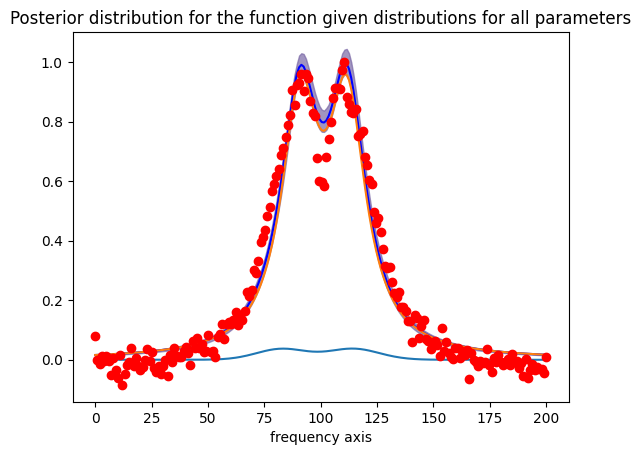

#################
measurement number 1


Sample: 100%|██████████| 1000/1000 [00:25, 39.06it/s, step size=4.46e-01, acc. prob=0.865]


#################


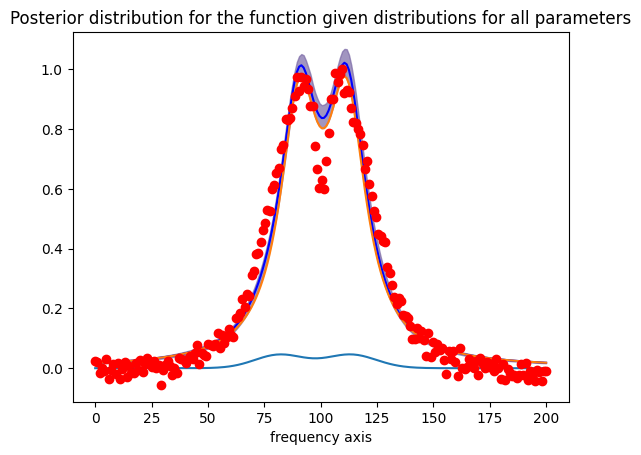

#################
measurement number 2


Sample: 100%|██████████| 1000/1000 [00:25, 39.73it/s, step size=3.12e-01, acc. prob=0.932]


#################


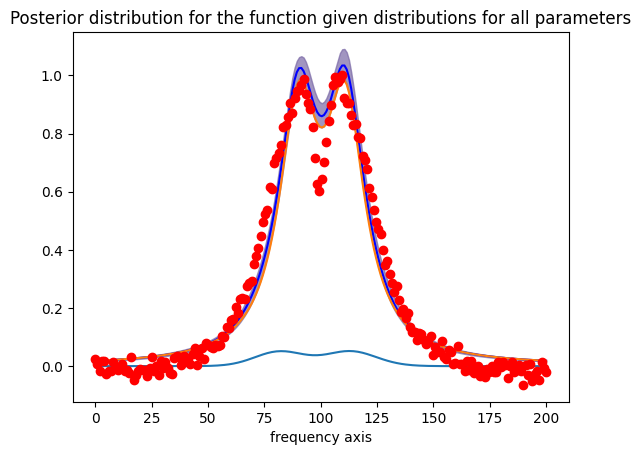

#################
measurement number 3


Sample: 100%|██████████| 1000/1000 [00:25, 39.49it/s, step size=3.43e-01, acc. prob=0.899]


#################


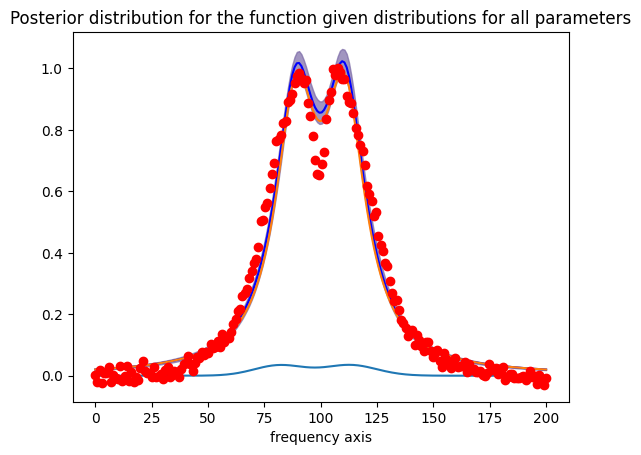

#################
measurement number 4


Sample: 100%|██████████| 1000/1000 [00:25, 39.34it/s, step size=2.91e-01, acc. prob=0.921]


#################


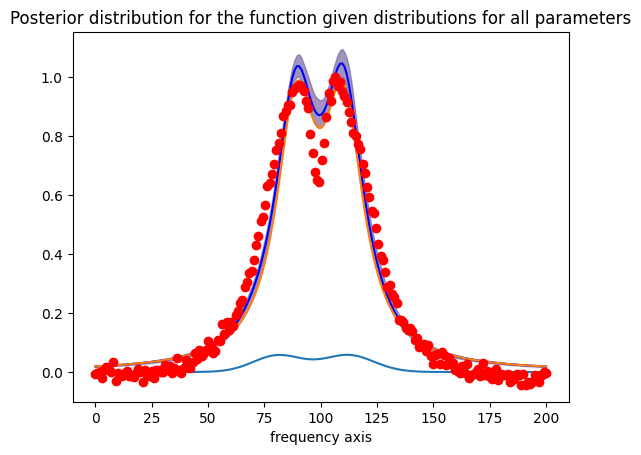

#################
measurement number 5


Sample: 100%|██████████| 1000/1000 [00:25, 39.24it/s, step size=3.35e-01, acc. prob=0.897]


#################


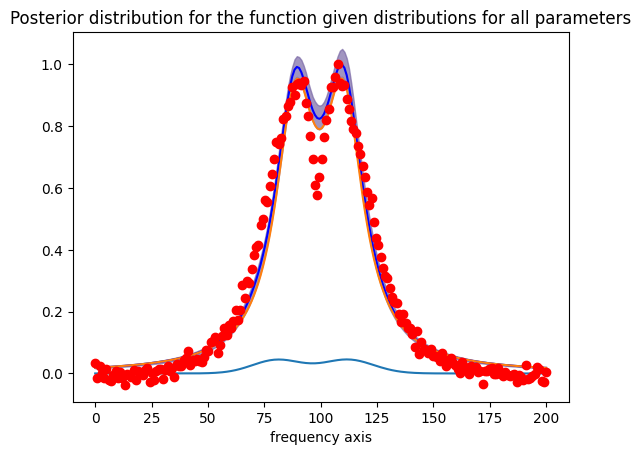

#################
measurement number 6


Sample: 100%|██████████| 1000/1000 [00:24, 40.29it/s, step size=3.35e-01, acc. prob=0.915]

#################


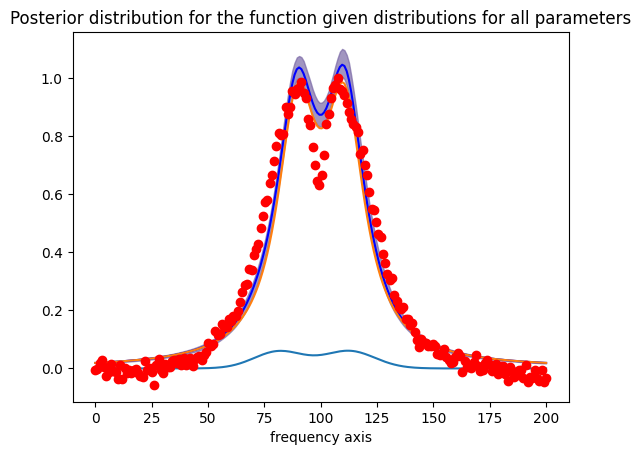

#################
measurement number 7


Sample: 100%|██████████| 1000/1000 [00:24, 40.45it/s, step size=3.57e-01, acc. prob=0.918]


#################


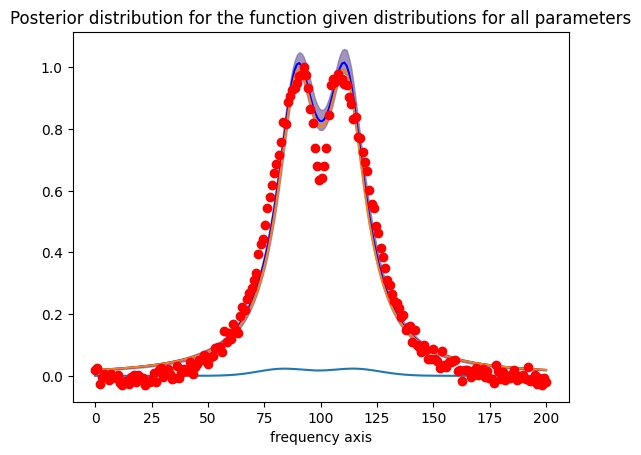

#################
measurement number 8


Sample: 100%|██████████| 1000/1000 [00:25, 39.58it/s, step size=3.38e-01, acc. prob=0.939]


#################


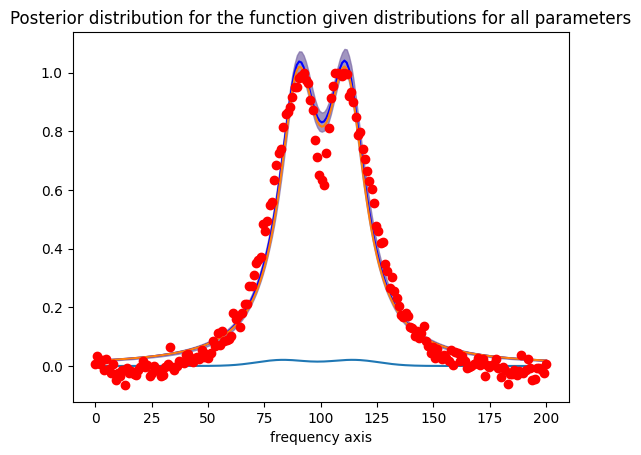

#################
measurement number 9


Sample: 100%|██████████| 1000/1000 [00:26, 37.97it/s, step size=3.39e-01, acc. prob=0.927]


#################


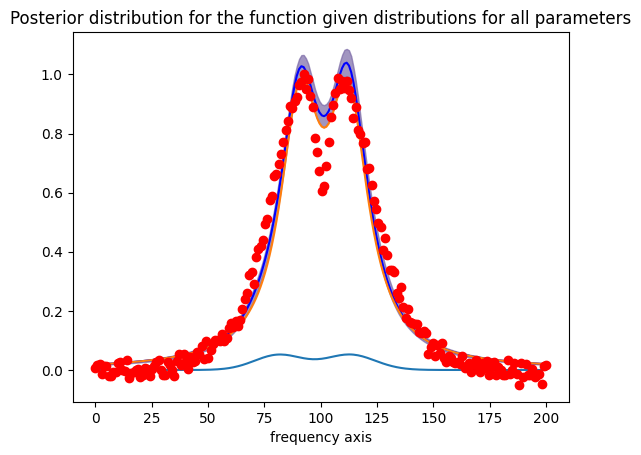

#################
measurement number 10


Sample: 100%|██████████| 1000/1000 [00:25, 38.77it/s, step size=3.27e-01, acc. prob=0.934]


#################


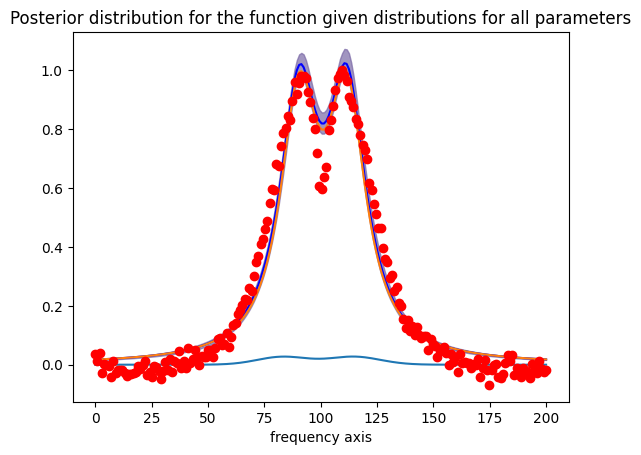

#################
measurement number 11


Sample: 100%|██████████| 1000/1000 [00:25, 39.61it/s, step size=4.03e-01, acc. prob=0.894]

#################


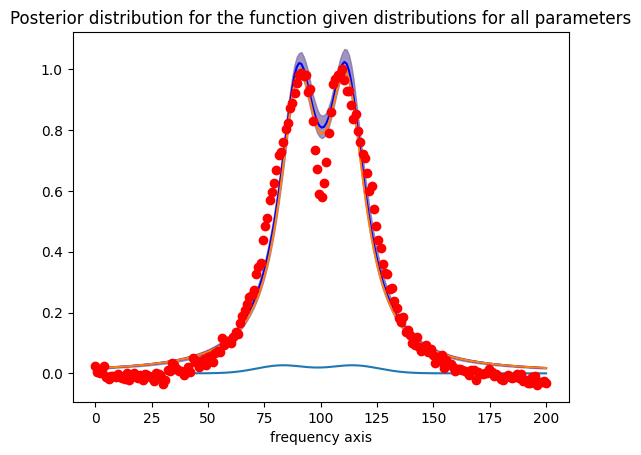

#################
measurement number 12


Sample: 100%|██████████| 1000/1000 [00:25, 39.47it/s, step size=3.38e-01, acc. prob=0.935]


#################


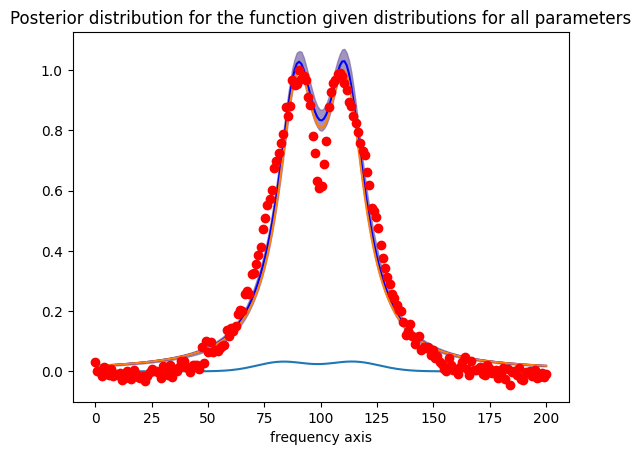

#################
measurement number 13


Sample: 100%|██████████| 1000/1000 [00:24, 41.48it/s, step size=2.65e-01, acc. prob=0.921]


#################


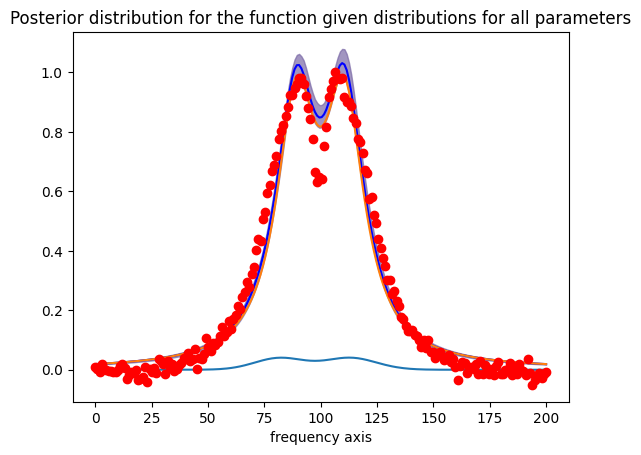

#################
measurement number 14


Sample: 100%|██████████| 1000/1000 [00:25, 38.48it/s, step size=3.53e-01, acc. prob=0.912]


#################


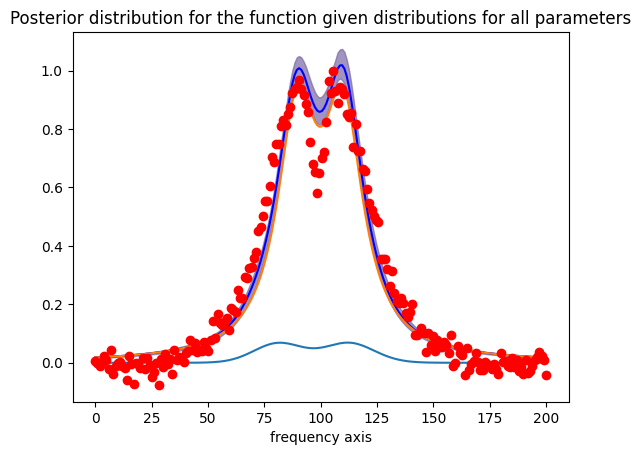

#################
measurement number 15


Sample: 100%|██████████| 1000/1000 [00:26, 37.89it/s, step size=3.89e-01, acc. prob=0.902]


#################


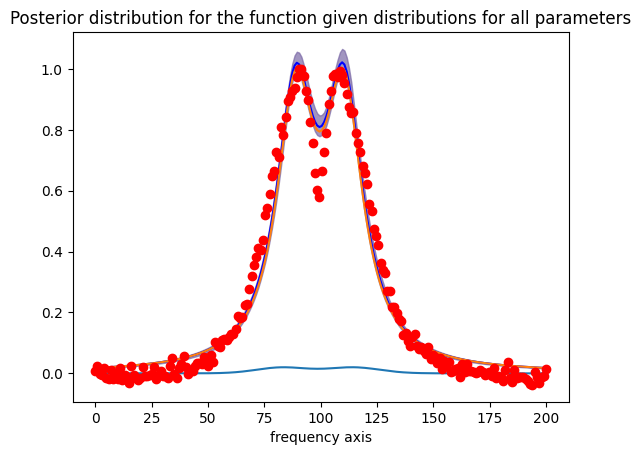

#################
measurement number 16


Sample: 100%|██████████| 1000/1000 [00:27, 36.56it/s, step size=3.21e-01, acc. prob=0.913]


#################


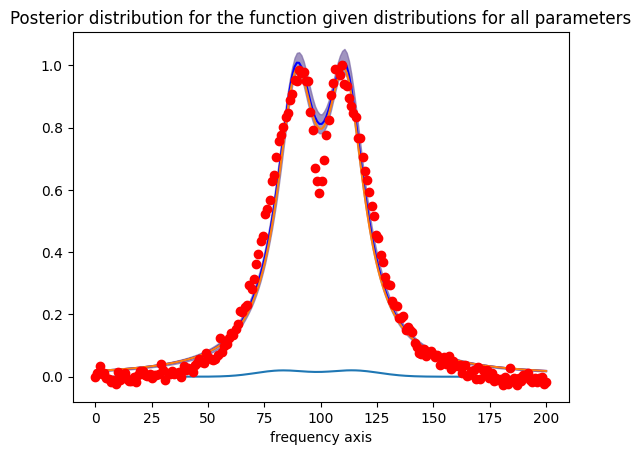

#################
measurement number 17


Sample: 100%|██████████| 1000/1000 [00:25, 38.70it/s, step size=3.93e-01, acc. prob=0.908]


#################


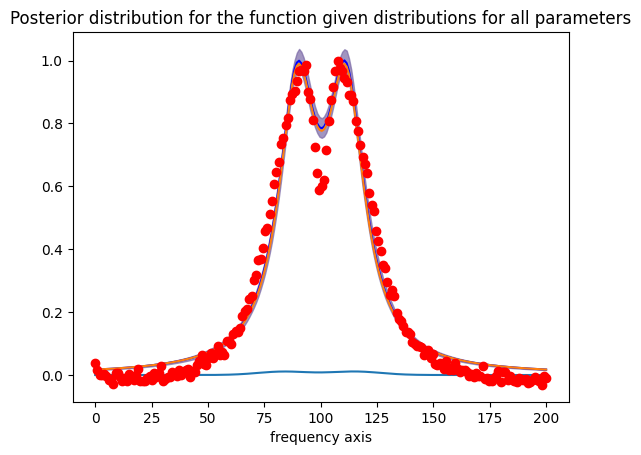

#################
measurement number 18


Sample: 100%|██████████| 1000/1000 [00:24, 40.24it/s, step size=3.06e-01, acc. prob=0.929]


#################


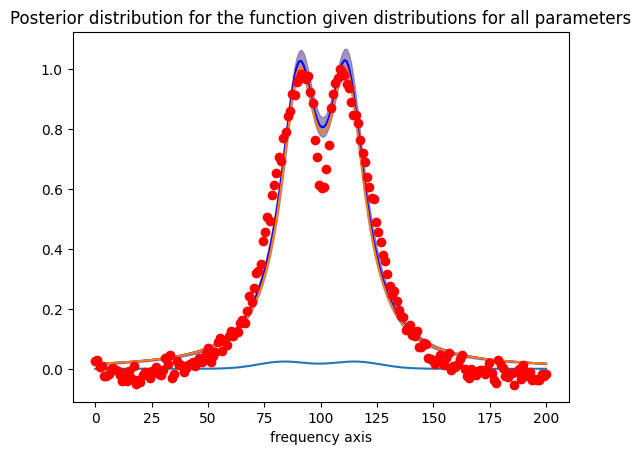

#################


In [208]:
idx = []
error_A = []
error_B = []
A_freq, B_freq = [], []
b_freq = []
#specify the kernel 
kernel = NUTS(model, jit_compile=True, init_strategy=init_to_value(values=init_vals), ignore_jit_warnings=True, max_tree_depth=3)

#loop over the data
for j in range(0, df_pcb.shape[1]-2):
  print(f'measurement number {j}')
  pyro.clear_param_store()
  x_obs_j, y_obs_j = dataslicer(x_esr_new, y_esr_new, col1=j, col2=j+1)
  data_j = (x_obs_j.clone().detach().double(), y_obs_j.clone().detach().double())
  posterior = MCMC(kernel, num_samples=500, warmup_steps=500, num_chains=1,  initial_params=init_vals)
  posterior.run(data_j)
  hmc_samples = {k: v.detach().cpu().numpy() for k, v in posterior.get_samples().items()}
  a1 = hmc_samples['a1'] 
  c1 = hmc_samples['c1'] 
  b1 = hmc_samples['b1'] 
  A = hmc_samples['A']
  X1 = hmc_samples['X1']
  X = hmc_samples['X']
  b2 = b1 + X1
  B = A + X
  var = hmc_samples['var'] 
  amp = hmc_samples['amp']
  gamma1 = hmc_samples['gamma1']
  F, F1, F2 = F_np(x_esr_new, a1, b1, c1, X1,  A, X, amp, gamma1)   #    x_esr_new, a1, b1, c1, X1, a2, c2, A, X, amp, gamma1, gamma2
  qs = mquantiles(F.T, [0.025, 0.975], axis=0)
  F_mean = F.mean(axis = 1) #/amp_.mean()
  F1_mean = F1.mean(axis=1)
  F2_mean = F2.mean(axis=1)
  idx.append(j)
  A_freq.append(A.mean())
  B_freq.append(B.mean())
  b_freq.append(b1.mean())
  error_A.append(A.var())
  error_B.append(B.var())
  print('#################')
  plt.fill_between(x_esr_new.flatten(), qs[0], qs[1], alpha=0.7, color="#7A68A6");
  plt.plot(x_obs, F_mean, 'b');
  plt.plot(x_obs, F1_mean);
  plt.plot(x_obs, F2_mean);
  plt.plot(x_obs_j, y_obs_j, 'ro'); # plotting the data for this slice
  plt.xlabel('frequency axis')
  plt.title('Posterior distribution for the function given distributions for all parameters');plt.show()
  pyro.clear_param_store()
  print('#################')

In [209]:
df_ = pd.DataFrame(zip(measured_temp, A_freq, b_freq), columns=['temp', 'a_freq', 'b_freq'])
df_.head(2)

,temp,a_freq,b_freq
0,25.0,90.791886,83.302171
1,30.0,90.505493,82.298121


Text(0, 0.5, 'Peak A')

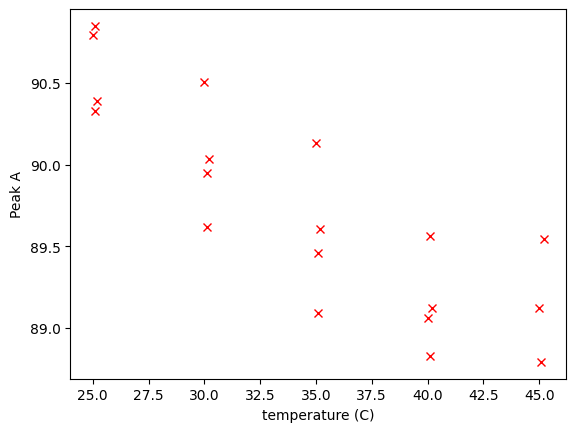

In [210]:
plt.plot(df_.temp, df_.a_freq, 'rx' )
plt.xlabel('temperature (C)')
plt.ylabel('Peak A')


## Let's build a linear regression model that maps centroid onto temperature



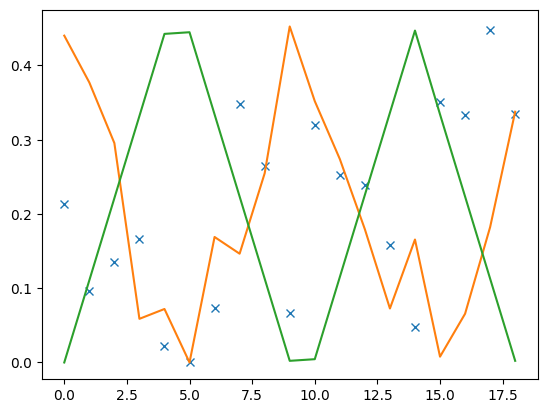

In [213]:
plt.plot(((df_.b_freq- df_.b_freq.min())/df_.b_freq.max())*10, "x")
plt.plot(((df_.a_freq -  df_.a_freq.min())/df_.a_freq.max())*20)
plt.plot((df_.temp - df_.temp.min())/df_.temp.max())

Testing RMSE:3.0243


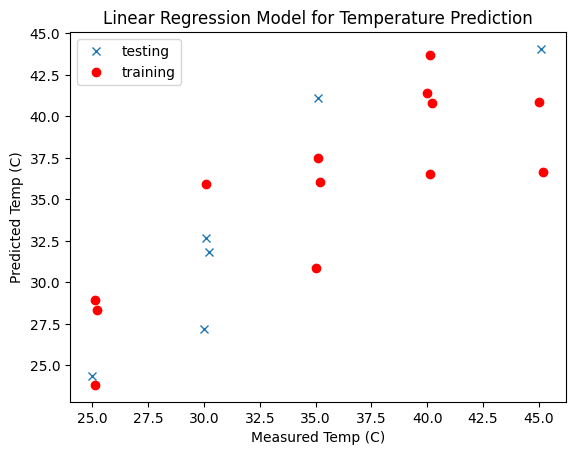

In [212]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

freq = df_.a_freq.values.reshape(-1,1)
df_.temp = df_.temp 
x_train, x_test, y_train, y_test = train_test_split(freq, df_.temp, test_size=0.3, random_state=42)

ln = LinearRegression()

ln.fit(x_train, y_train)
temp_pred = ln.predict(x_test)

plt.plot(y_test, temp_pred, 'x'); plt.plot(y_train, ln.predict(x_train), 'ro')
plt.legend(['testing', 'training'])
mse = mean_squared_error(y_test, temp_pred)
print(f'Testing RMSE:{np.sqrt(mse):.4f}')
plt.xlabel('Measured Temp (C)'); plt.ylabel('Predicted Temp (C)'); plt.title('Linear Regression Model for Temperature Prediction');

In [ ]:
plt.plot(freq, df_.temp, 'o-', label='peak A')

In [ ]:
1/ln.coef_

In [ ]:
1/ln.intercept_